<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


Saving runaway.png to runaway.png


(np.float64(-0.5), np.float64(709.5), np.float64(716.5), np.float64(-0.5))

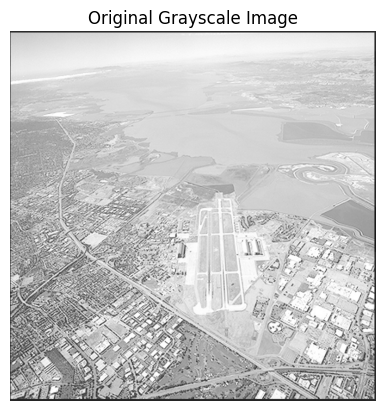

In [ ]:
# Upload image
uploaded = files.upload()

# Read image (replace filename if needed)
img = cv2.imread(list(uploaded.keys())[0], cv2.IMREAD_GRAYSCALE)

# Display original image
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')


In [ ]:
def bilateral_filter_manual(image, diameter, sigma_s, sigma_r):
    """
    Manual implementation of bilateral filter for grayscale images
    """
    padded_img = np.pad(image, diameter//2, mode='reflect')
    filtered_img = np.zeros_like(image, dtype=np.float64)

    # Precompute spatial Gaussian
    radius = diameter // 2
    x, y = np.meshgrid(np.arange(-radius, radius+1),
                       np.arange(-radius, radius+1))
    spatial_gaussian = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded_img[i:i+diameter, j:j+diameter]

            # Range Gaussian
            intensity_diff = region - image[i, j]
            range_gaussian = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))

            # Bilateral filter weights
            weights = spatial_gaussian * range_gaussian
            weights /= np.sum(weights)

            filtered_img[i, j] = np.sum(region * weights)

    return filtered_img.astype(np.uint8)


(np.float64(-0.5), np.float64(709.5), np.float64(716.5), np.float64(-0.5))

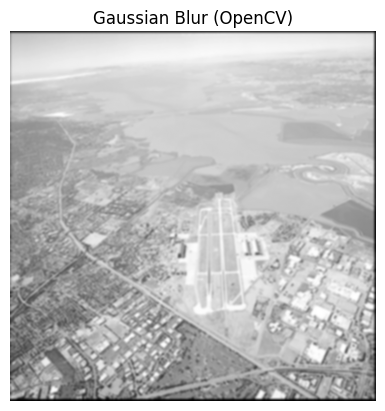

In [ ]:
gaussian_blur = cv2.GaussianBlur(img, (9, 9), sigmaX=2)

plt.imshow(gaussian_blur, cmap='gray')
plt.title("Gaussian Blur (OpenCV)")
plt.axis('off')


(np.float64(-0.5), np.float64(709.5), np.float64(716.5), np.float64(-0.5))

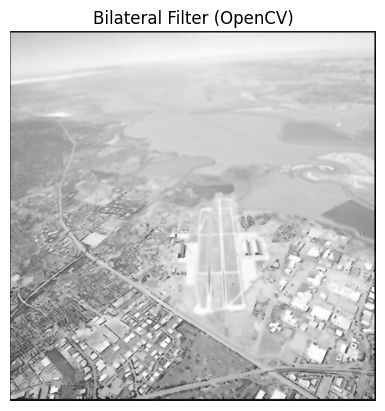

In [ ]:
bilateral_opencv = cv2.bilateralFilter(
    img,
    d=9,
    sigmaColor=50,
    sigmaSpace=50
)

plt.imshow(bilateral_opencv, cmap='gray')
plt.title("Bilateral Filter (OpenCV)")
plt.axis('off')


(np.float64(-0.5), np.float64(709.5), np.float64(716.5), np.float64(-0.5))

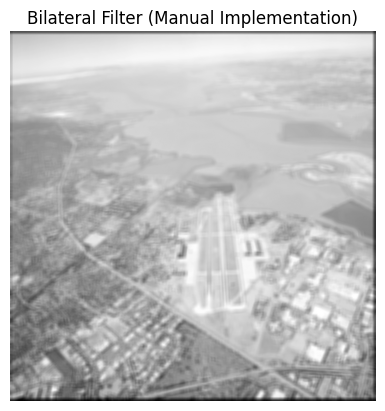

In [ ]:
bilateral_manual = bilateral_filter_manual(
    img,
    diameter=9,
    sigma_s=50,
    sigma_r=50
)

plt.imshow(bilateral_manual, cmap='gray')
plt.title("Bilateral Filter (Manual Implementation)")
plt.axis('off')


(np.float64(-0.5), np.float64(709.5), np.float64(716.5), np.float64(-0.5))

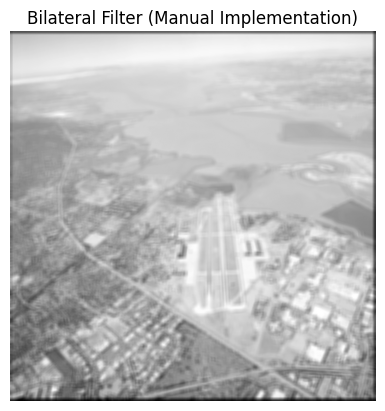

In [ ]:
bilateral_manual = bilateral_filter_manual(
    img,
    diameter=9,
    sigma_s=50,
    sigma_r=50
)

plt.imshow(bilateral_manual, cmap='gray')
plt.title("Bilateral Filter (Manual Implementation)")
plt.axis('off')


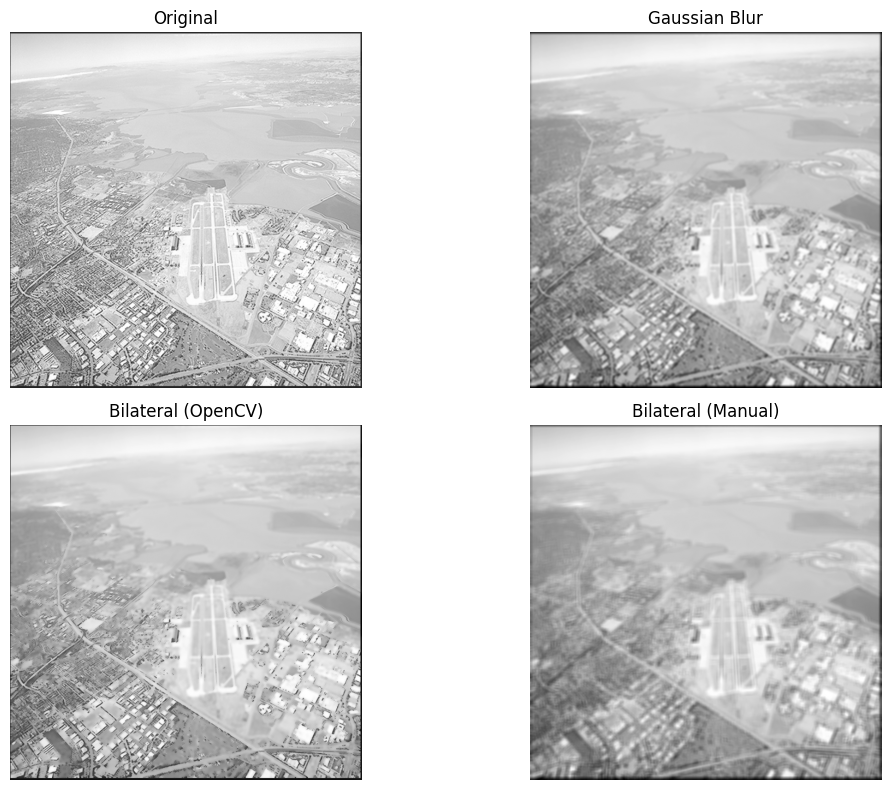

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(gaussian_blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(bilateral_opencv, cmap='gray')
plt.title("Bilateral (OpenCV)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(bilateral_manual, cmap='gray')
plt.title("Bilateral (Manual)")
plt.axis('off')

plt.tight_layout()
plt.show()
